<img src="./logo_UTN.svg" align="right" width="150" /> 

# Teoría de Circuitos II

## TP LAB

Autor:
*Facundo Nahuel Sussini*

Integrantes del grupo :
*Juan Pablo Maurin* - *Diego Nicolás Gonzalez* 

Curso: 
*R4052*

Docentes: 
*Mariano Llamedo Soria* - *David Santiago Moharos*    

In [8]:
# --- Módulos para Jupyter ---
import warnings
warnings.filterwarnings('ignore')

# --- Módulos importantes ---
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from scipy.signal import group_delay
from pytc2.sistemas_lineales import plot_plantilla



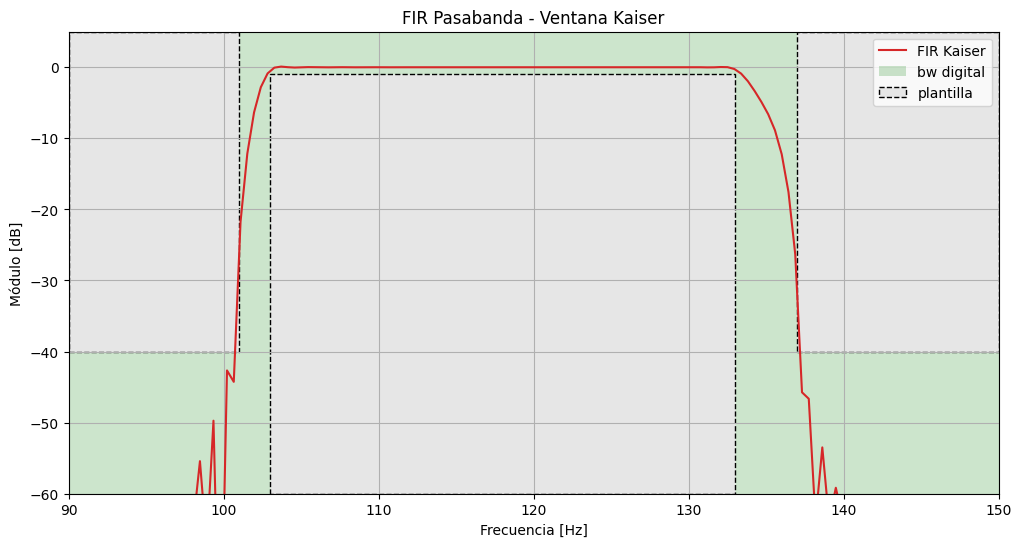

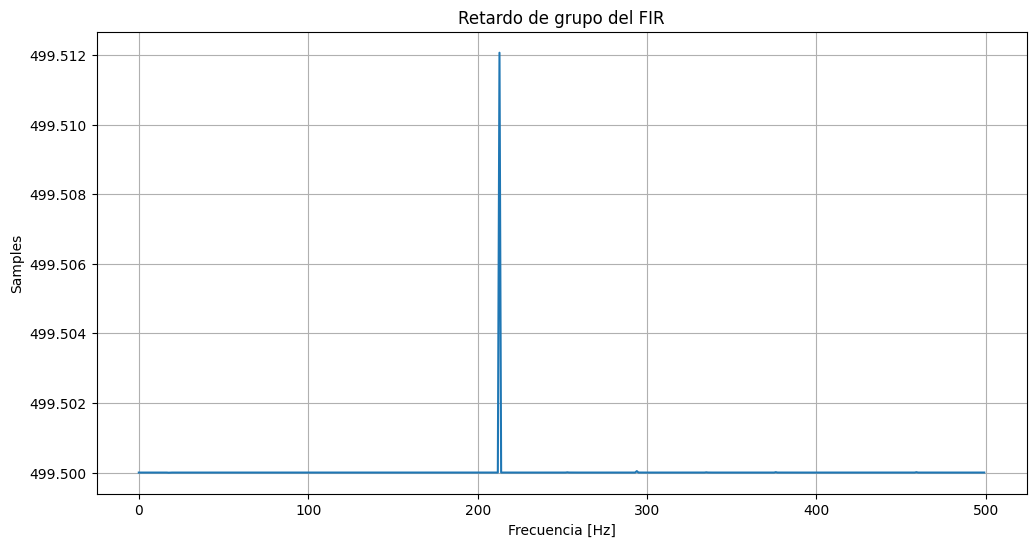

In [9]:
# =====================================================
#   Diseño FIR pasa-banda con ventana de Kaiser
# =====================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from scipy.signal import group_delay
from pytc2.sistemas_lineales import plot_plantilla

# --- Parámetros del FIR ---
cant_coeficientes = 1000
cte = 100  # desplazamiento visual

ws1_filt = 1  + cte  # 101 Hz
wp1_filt = 3  + cte  # 103 Hz
wp2_filt = 33 + cte  # 133 Hz
ws2_filt = 37 + cte  # 137 Hz

# --- Parámetros generales ---
fs = 1000        # frecuencia de muestreo [Hz]
nyq_frec = fs/2  # 500 Hz
ripple = 1       # dB
atenuacion = 40  # dB

# --- Parámetros gráficos ---
fig_sz_x = 12
fig_sz_y = 6

# =====================================================
#   Diseño del FIR
# =====================================================

num_win = sig.firwin2(
    cant_coeficientes,
    freq=(0, ws1_filt, wp1_filt, wp2_filt, ws2_filt, nyq_frec),
    gain=(0, 0, 1, 1, 0, 0),
    window=('kaiser', 1),
    fs=fs
)
den = 1.0  # denominador FIR

# --- Respuesta en frecuencia (en dB) ---
w_rad = np.append(np.logspace(-3, 0.8, 1000), np.logspace(0.9, 1.8, 1000))
w_rad = np.append(w_rad, np.linspace(64, nyq_frec, 1000, endpoint=True))

w_rad, h_fir = sig.freqz(num_win, den, worN=w_rad, fs=fs)

# =====================================================
#   Gráfica: FIR + Plantilla en una sola figura
# =====================================================

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.plot(w_rad, 20 * np.log10(np.abs(h_fir) + 1e-12), label='FIR Kaiser', color='C3')

plt.title('FIR Pasabanda - Ventana Kaiser')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([90, 150, -60, 5])

axes_hdl = plt.gca()

# --- Plantilla sobre el mismo gráfico ---
plot_plantilla(
    filter_type='bandpass',
    fpass=(wp1_filt, wp2_filt),
    fstop=(ws1_filt, ws2_filt),
    ripple=ripple,
    attenuation=atenuacion,
    fs=fs
)
_ = axes_hdl.legend()

# =====================================================
#   Retardo de grupo (en otra figura)
# =====================================================

w_gd, gd = group_delay((num_win, den), fs=fs)
plt.figure(2, figsize=(fig_sz_x, fig_sz_y))
plt.plot(w_gd, gd)
plt.title('Retardo de grupo del FIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Samples')
plt.grid()
plt.show()


# Introducción

### Objetivos
* Consolidar los conceptos de los sistemas muestreados mediante el uso de ADC y DACs.
* Simular e implementar un filtro digital con el STM NUCLEO-64
* Familiarizarse con el uso de librerías para procesamiento digital de señales.
* Medir las partes de la función transferencia H[z] para frecuencias entre 10 Hz y 10 kHz.


### Descripción

El trabajo práctico tiene como objetivo la implementación de funciones transferencias digitales utilizando como procesador de señales el STM NUCLEO-64.


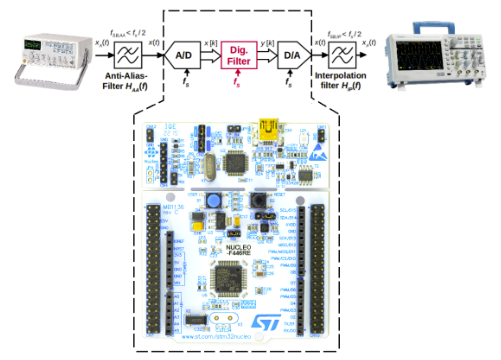

**Plantillas de diseño**:

Se implementarán los filtros obtenidos de la Tarea Semanal 9: Laboratorio de filtros digitales.


# IIR

Primero, se analizara un filtro IIR, identico al realizado en la Tarea semanal 9

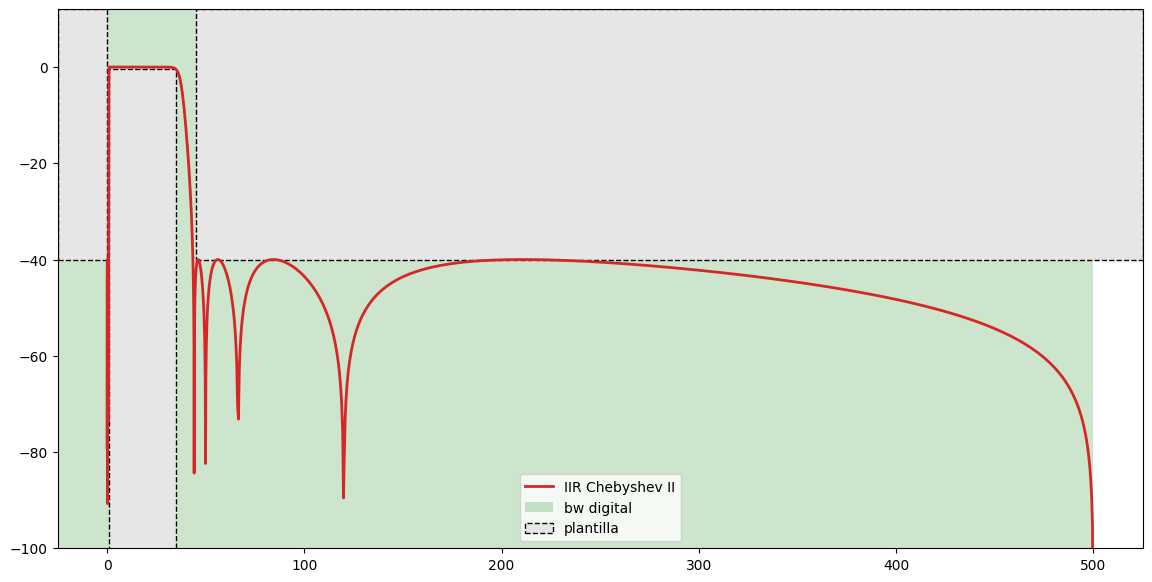

In [10]:
# =====================================================
#   Plantilla + Diseño IIR Chebyshev II en una sola figura
# =====================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from pytc2.sistemas_lineales import plot_plantilla

# --- Parámetros del filtro y plantilla ---
ripple = 0.5      # dB de ripple en banda de paso
atenuacion = 40   # dB de atenuación en banda de rechazo

cte = 0            # desplazamiento opcional
ws1 = 0.1          # Hz
wp1 = 1            # Hz
wp2 = 35.0         # Hz
ws2 = 45.0         # Hz

fs = 1000          # frecuencia de muestreo [Hz]
nyq_frec = fs / 2

# --- Parámetros de figura ---
fig_sz_x = 14
fig_sz_y = 7

# =====================================================
#   Diseño del filtro IIR
# =====================================================
sos_iir = sig.iirdesign(
    wp=[wp1, wp2],
    ws=[ws1, ws2],
    gpass=ripple,
    gstop=atenuacion,
    output='sos',
    analog=False,
    ftype='cheby2',
    fs=fs
)

# --- Respuesta en frecuencia ---
# Mismo tipo de barrido que usás para FIR e IIR
w_rad = np.append(np.logspace(-3, 0.8, 1000), np.logspace(0.9, 1.8, 1000))
w_rad = np.append(w_rad, np.linspace(64, nyq_frec, 1000, endpoint=True))
w_rad, h_iir = sig.freqz_sos(sos_iir, worN=w_rad, fs=fs)

# =====================================================
#   Gráfico conjunto: plantilla + respuesta IIR
# =====================================================
plt.figure(1, figsize=(fig_sz_x, fig_sz_y))

# Curva de magnitud del filtro
plt.plot(w_rad, 20*np.log10(np.abs(h_iir) + 1e-12),
         label='IIR Chebyshev II', color='C3', linewidth=2)

# Plantilla de diseño superpuesta
plot_plantilla(
    filter_type='bandpass',
    fpass=(wp1, wp2),
    fstop=(ws1, ws2),
    ripple=ripple,
    attenuation=atenuacion,
    fs=fs
)



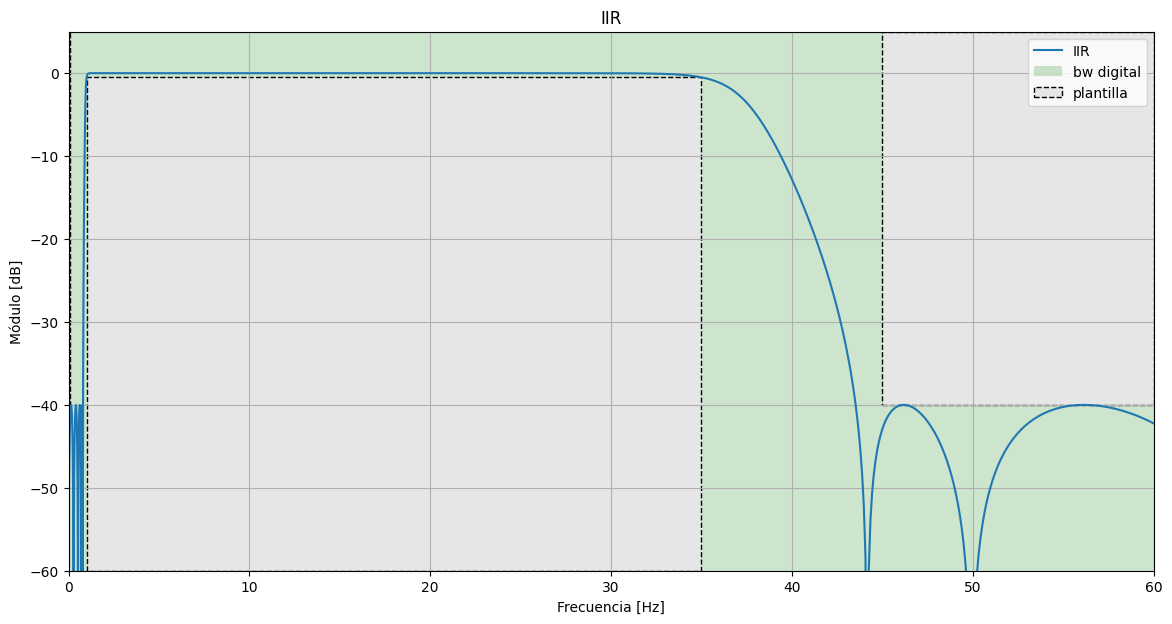

In [11]:
# @title Filtro IIR_DESIGN

sos_iir = sig.iirdesign(wp= [wp1,wp2], ws=[ws1,ws2], gpass=ripple, gstop=atenuacion, output='sos', analog=False, ftype='cheby2', fs = fs)

sos_iir_1 = sos_iir
w_rad  = np.append(np.logspace(-3, 0.8, 1000), np.logspace(0.9, 1.8, 1000) )
w_rad  = np.append(w_rad, np.linspace(64, nyq_frec, 1000, endpoint=True) )

w_rad, h_iir = sig.freqz_sos(sos_iir, worN=w_rad, fs = fs)

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))

plt.plot(w_rad, 20*np.log10(np.abs(h_iir)+1e-12), label = 'IIR' )

plt.title('IIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([0, 60, -60, 5 ]);

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
_ = axes_hdl.legend()

# Respuesta del filtro

### 121 mHZ *(Banda de stop inferior)*
Se observa como la señal, esta totalmente atenuada. Coincidiendo con el resultado del filtro
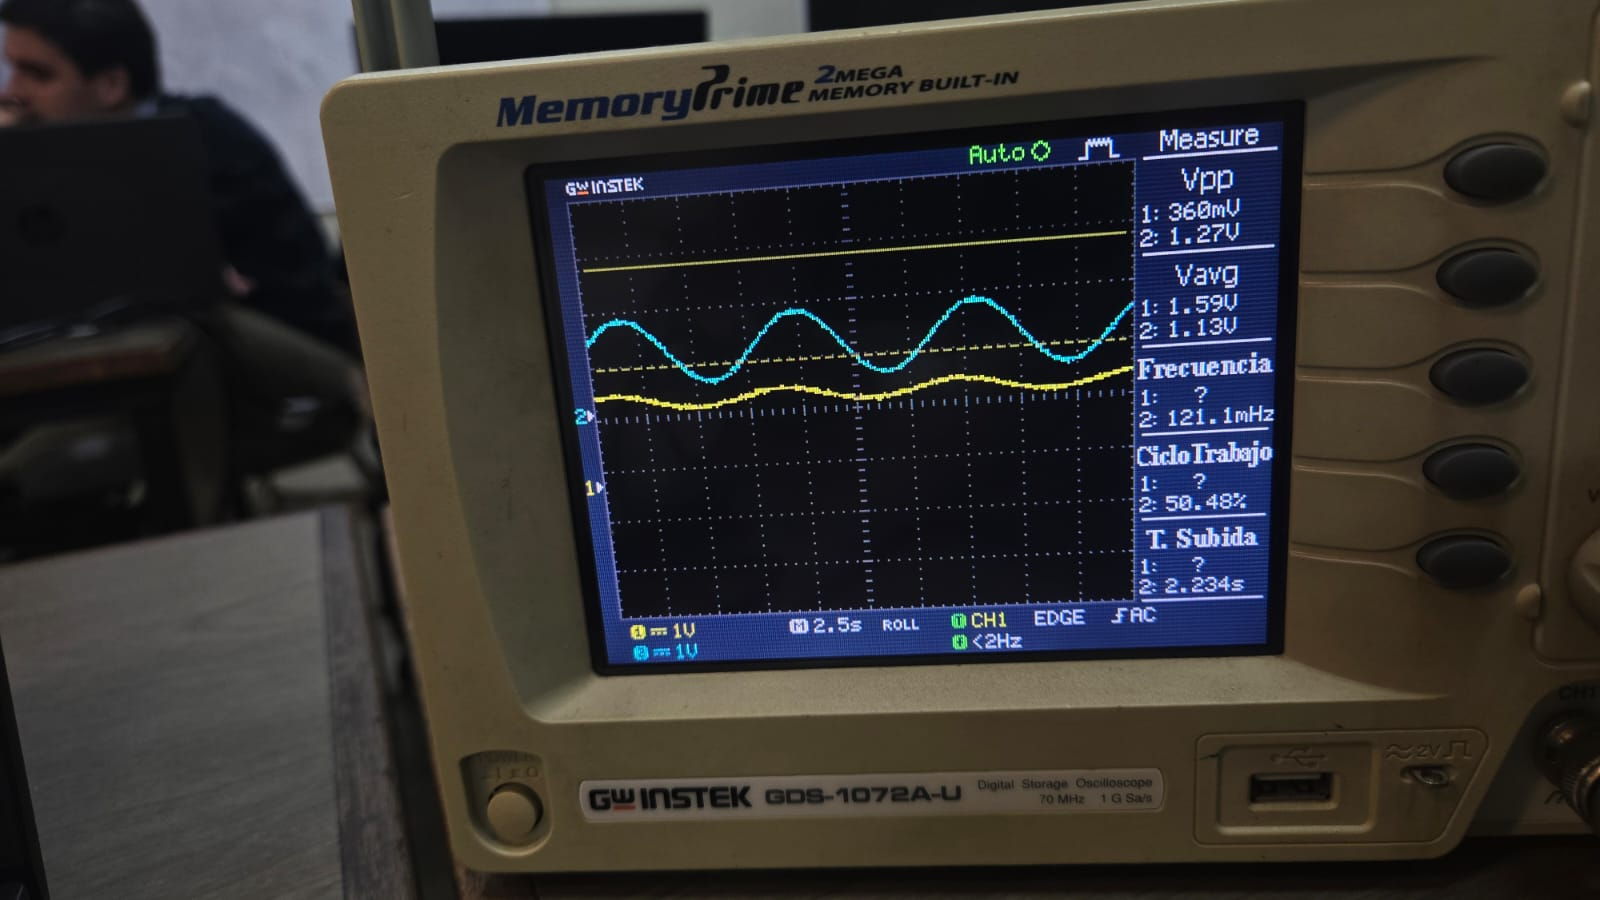

### 1 HZ *(Banda de paso inferior)*
Como en 1 Hz, comienza la banda de paso. Se comienza a observar la señal nuevamente
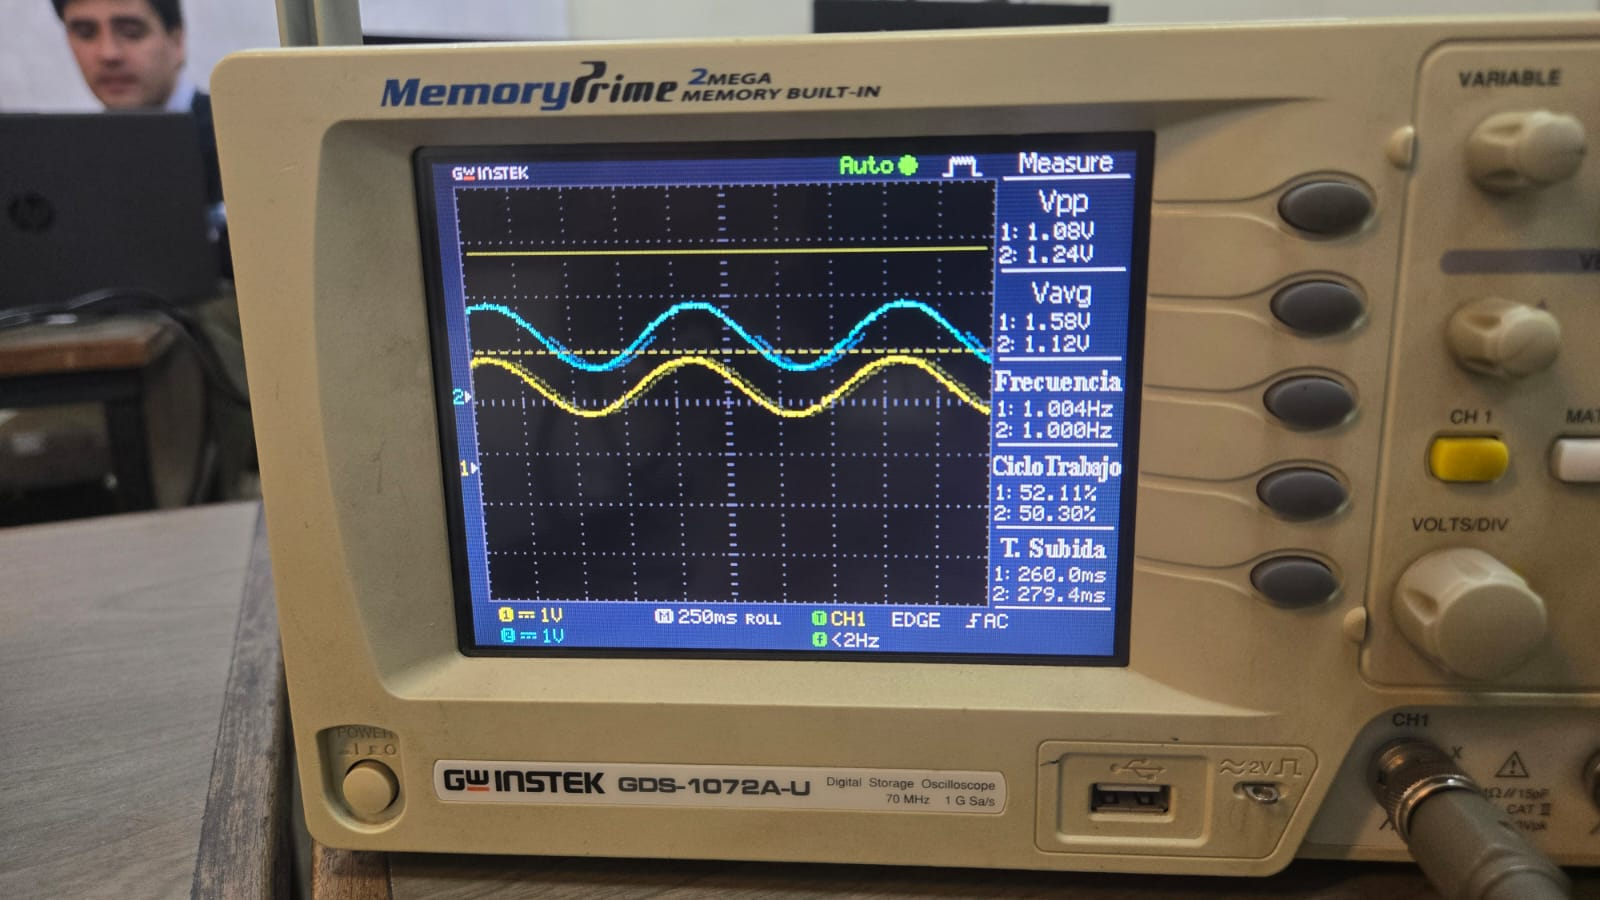

### 23 HZ *(Banda de paso superior)*
Se observa como la señal, Al estar tambien en banda de paso, no se modifica (exceptuando su fase)
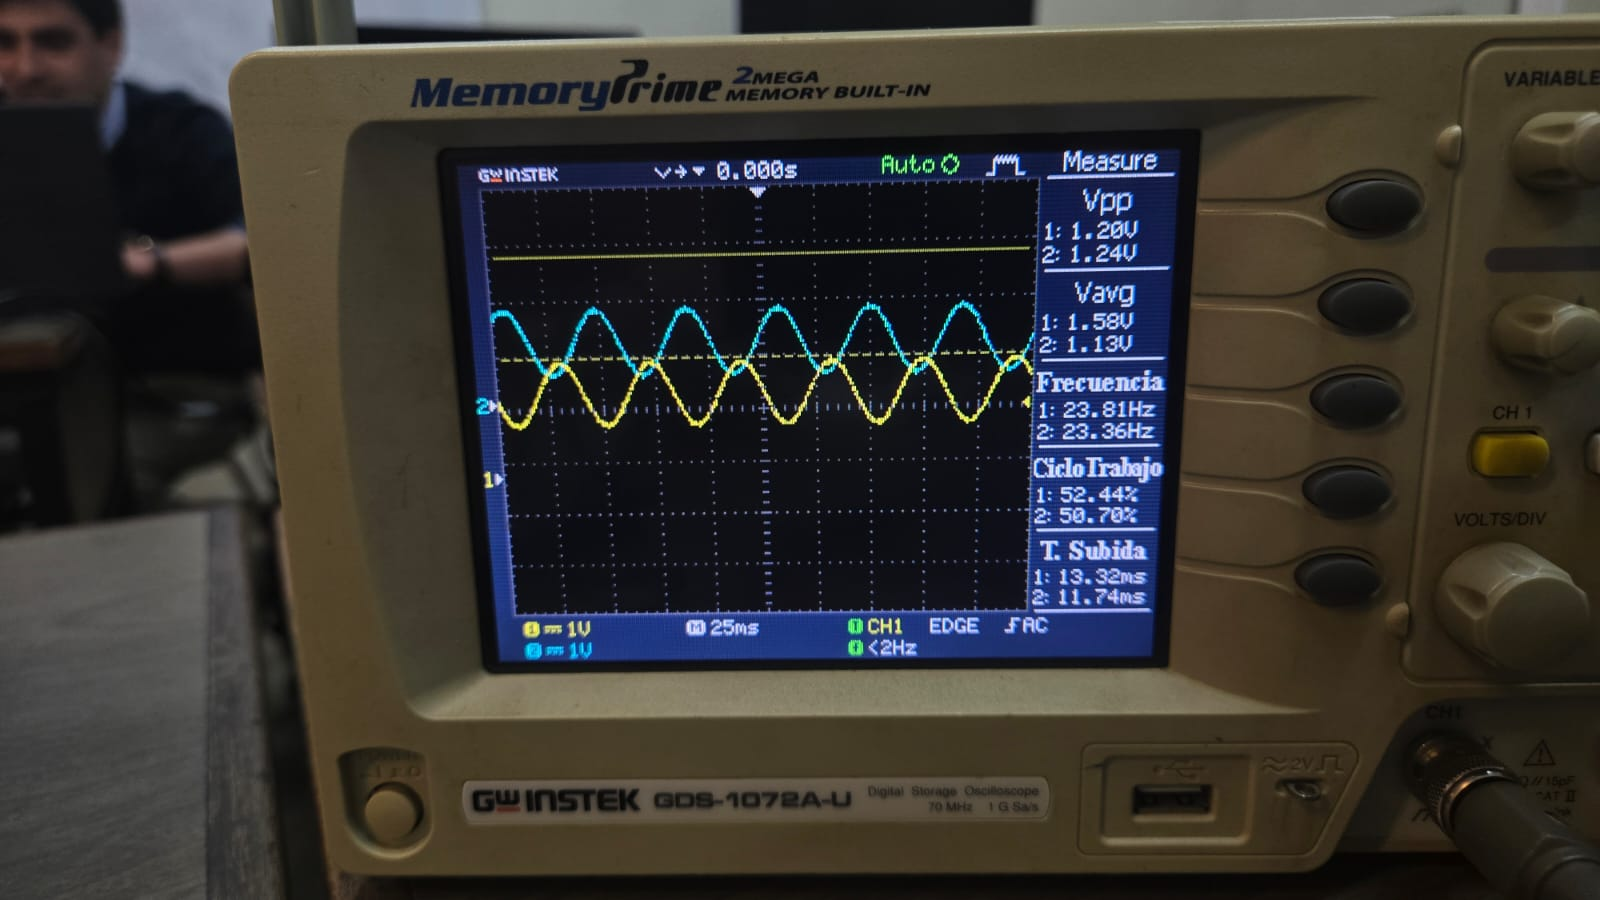

### 45 HZ *(Banda de stop superior)*
En esta frecuencia, ya nos encontramos en la banda de stop, por lo que la señal se encuentra fuertemente atenuada
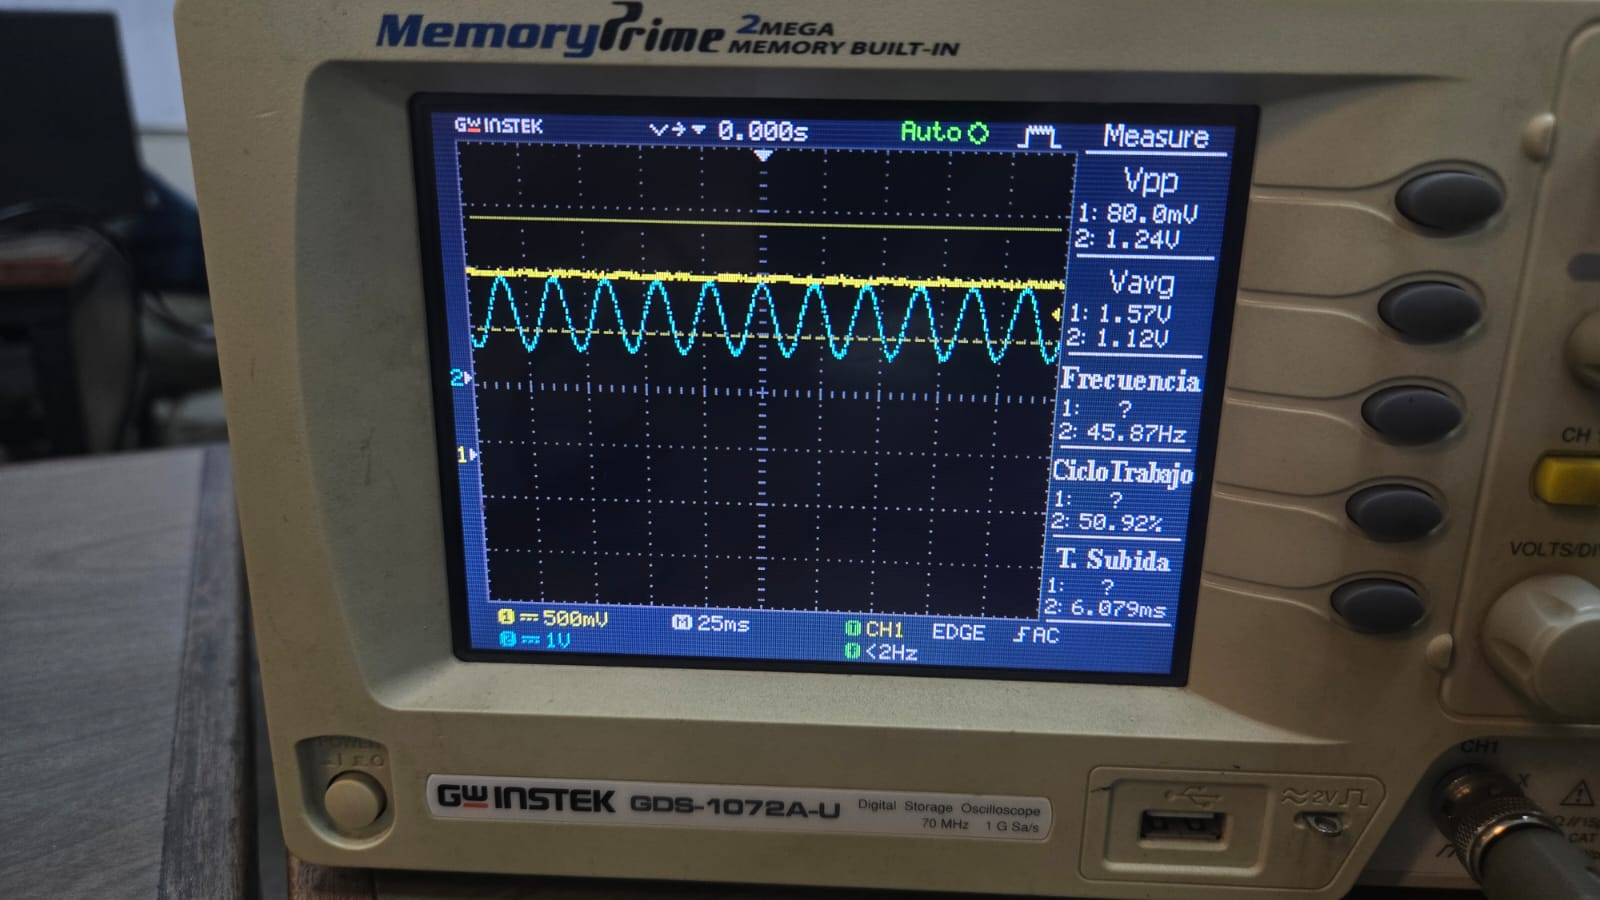

---
---

# FIR 

Para poder realizar un analisis mas preciso y comodo con el analizador de espectro y el generador de señales. Se "corre" la respuesta del filtro a frecuencias mas altas

Adicionalmente, se reduce levemente la exigencia del filtro. De esta forma se obtienen filtros de menor ordenes, que son mas sencillos de implementar


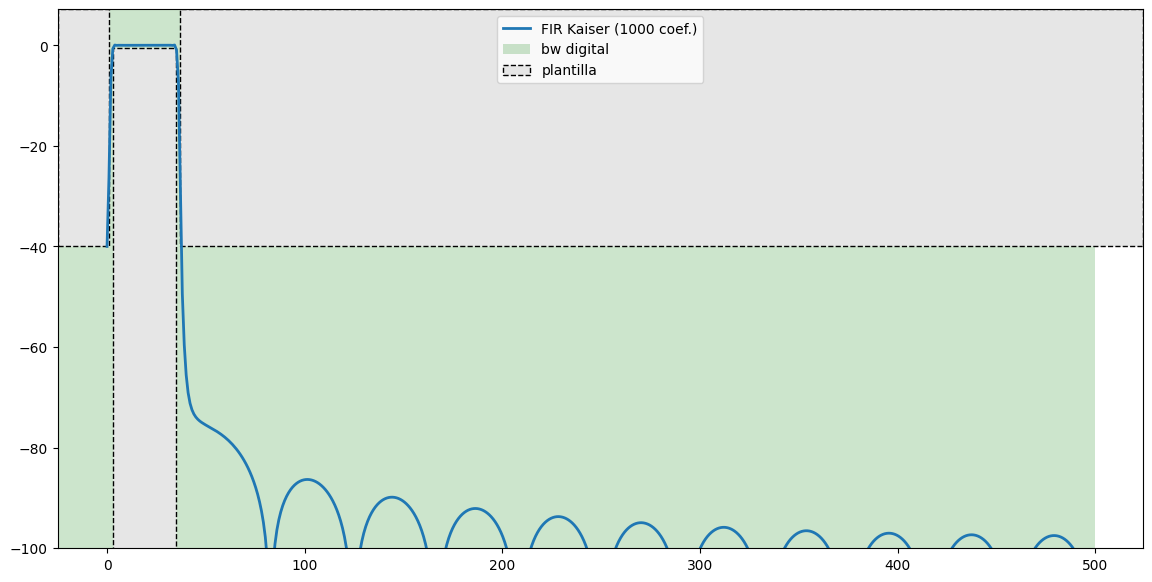

In [12]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from pytc2.sistemas_lineales import plot_plantilla

# =========================================================
# Parámetros generales
# =========================================================
ripple = 0.5        # dB
atenuacion = 40     # dB
fs = 1000           # Hz
nyq_frec = fs / 2
fig_sz_x = 14
fig_sz_y = 7

# =========================================================
# Parámetros del FIR
# =========================================================
cant_coeficientes = 1000
ws1_filt = 1      # Hz
wp1_filt = 3      # Hz
wp2_filt = 35     # Hz
ws2_filt = 37     # Hz

# =========================================================
# Diseño FIR (ventaneo Kaiser)
# =========================================================
num_win = sig.firwin2(
    cant_coeficientes,
    freq=(0, ws1_filt, wp1_filt, wp2_filt, ws2_filt, nyq_frec),
    gain=(0, 0, 1, 1, 0, 0),
    window=('kaiser', 1),
    fs=fs
)
den = 1.0

# =========================================================
# Respuesta en frecuencia
# =========================================================
w, hh_win = sig.freqz(num_win, den, fs=fs)
H_dB = 20 * np.log10(np.abs(hh_win) + 1e-12)

# =========================================================
# Gráfico conjunto: plantilla + FIR
# =========================================================
plt.figure(figsize=(fig_sz_x, fig_sz_y))

# --- Respuesta del FIR ---
plt.plot(w, H_dB, label=f'FIR Kaiser ({cant_coeficientes} coef.)', color='C0', linewidth=2)

# --- Plantilla del filtro (tipo banda pasante) ---
plot_plantilla(
    filter_type='bandpass',
    fpass=(wp1_filt, wp2_filt),
    fstop=(ws1_filt, ws2_filt),
    ripple=ripple,
    attenuation=atenuacion,
    fs=fs
)


# Respuesta del filtro

La banda de paso, esta entre 1.1 hz y 35.1 hz aproximadamente


### 1 Hz y 500mHz *(Banda de stop inferior)*
Se observa como la señal, esta totalmente atenuada. Coincidiendo con el resultado del filtro, cuya banda de paso comienza en 1.1Hz
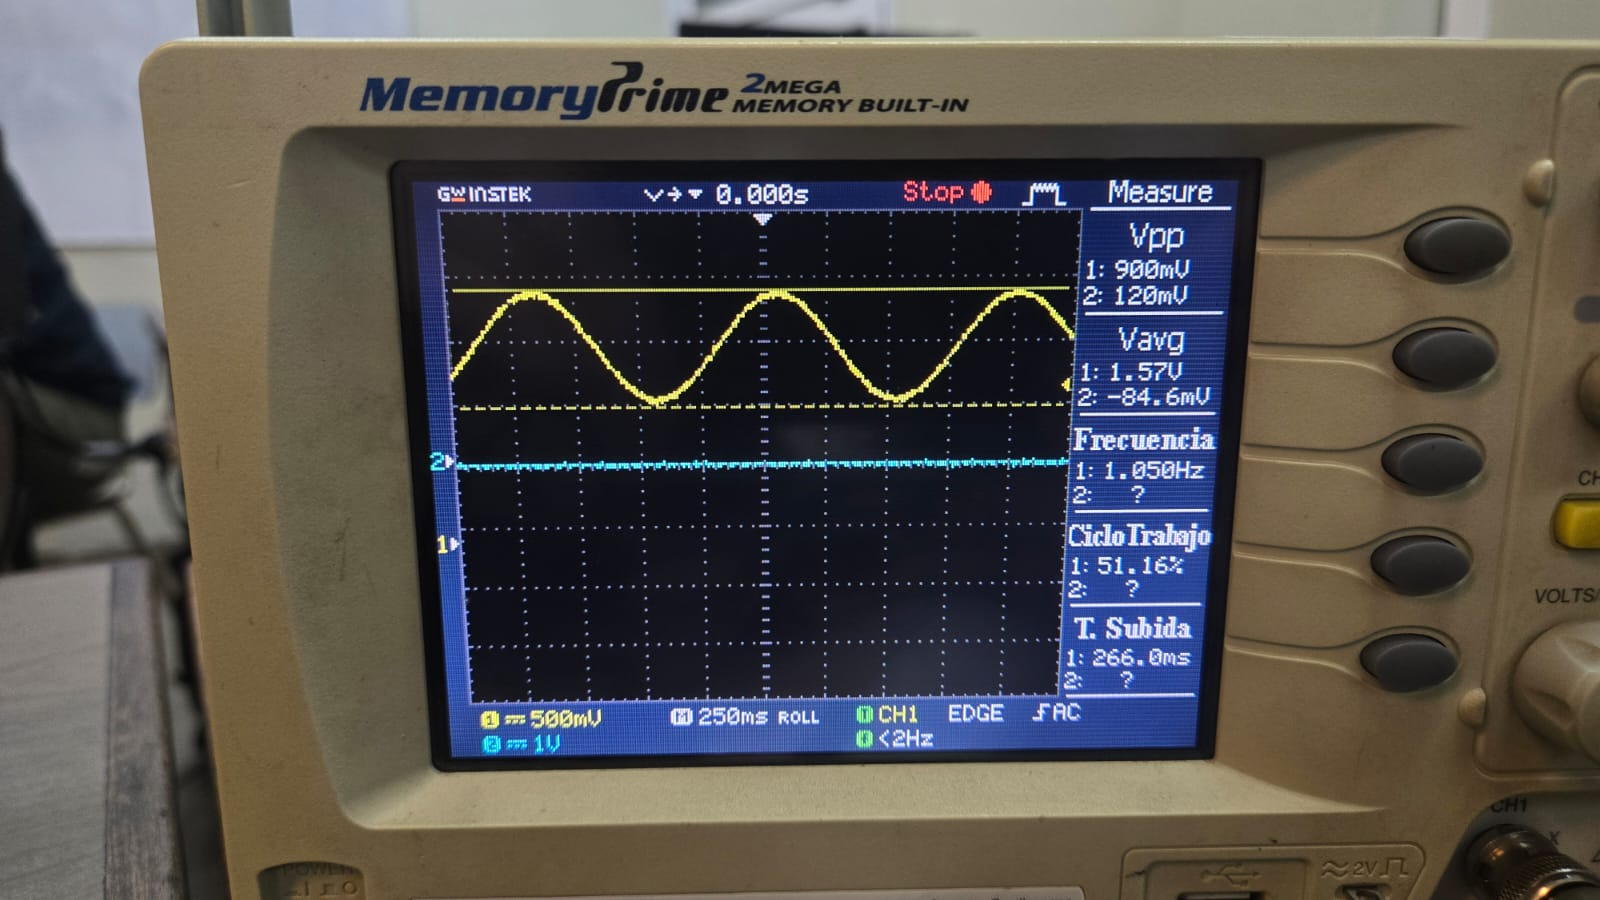
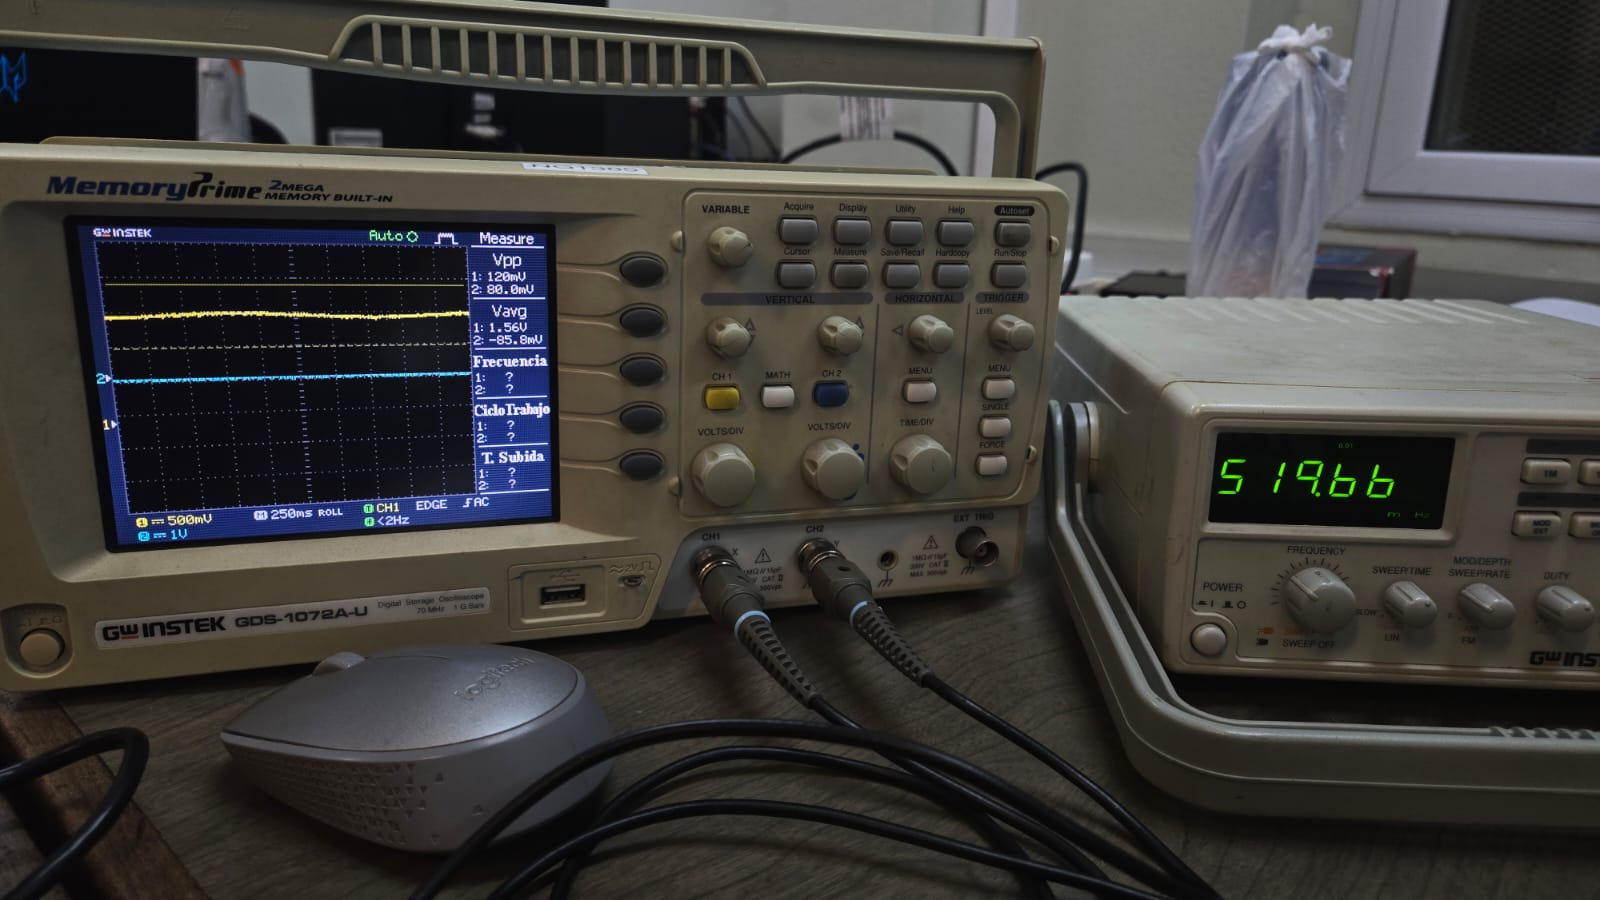

### 29Hz *(Banda de paso)*
Se observa como la señal, Al estar tambien en banda de paso, no se atenua
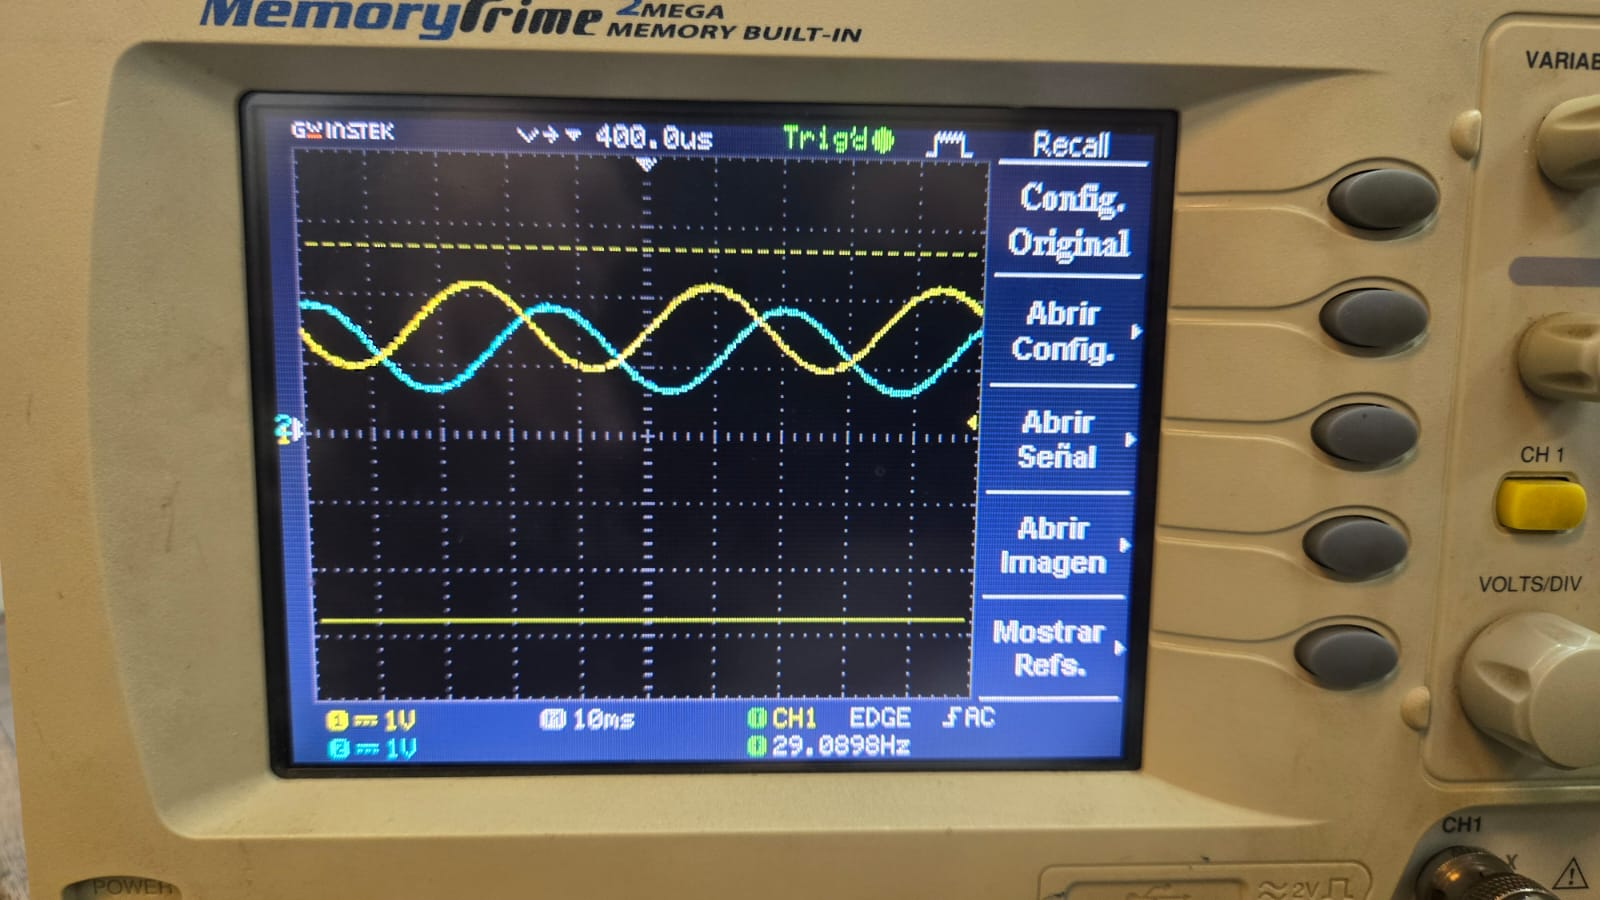



## Analizador de Espectro

Para poder realizar un analisis mas preciso y comodo con el analizador de espectro y el generador de señales. Se "correra" la respuesta del filtro a frecuencias mas altas (manteniendo la exigencia del mismo)

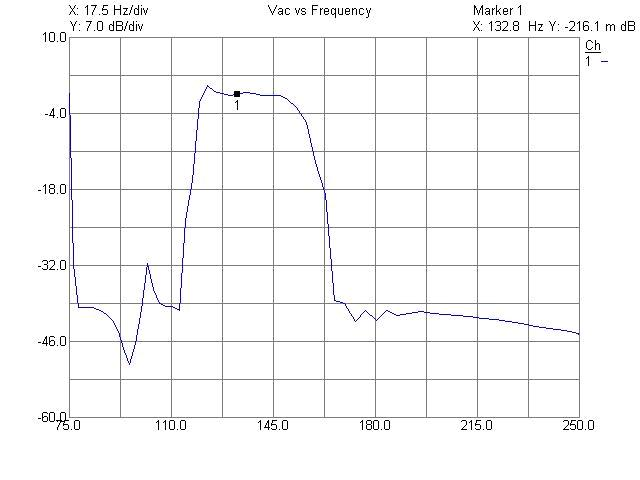

En este caso, se observa que la respuesta del analizador de espectro, NO CUMPLE con la indicada.

Se ve claramente, como la misma esta fuertemente desplazada. Sin embargo, se cumple con el ancho de banda especificado (aproximadamente 30 Hz), ademas de la estricticidad del filtro.

Se estima que esto puede ser producto de una irregularidad en la frecuencia de mustreo de la plaqueta. Ya que en tal caso, el filtro diseñado se desplazaria en frecuencia, lo cual coincide con lo observado.

---
---

# IIR - Corrido

Al igual que con el FIR, se "corre" la respuesta en frecuencia hacia una banda que sea mas apreciable desde el analizador.

Adicionalmente, se reduce la exigencia del filtro. De esta forma se obtienen filtros de menor ordenes, que son mas sencillos de implementar

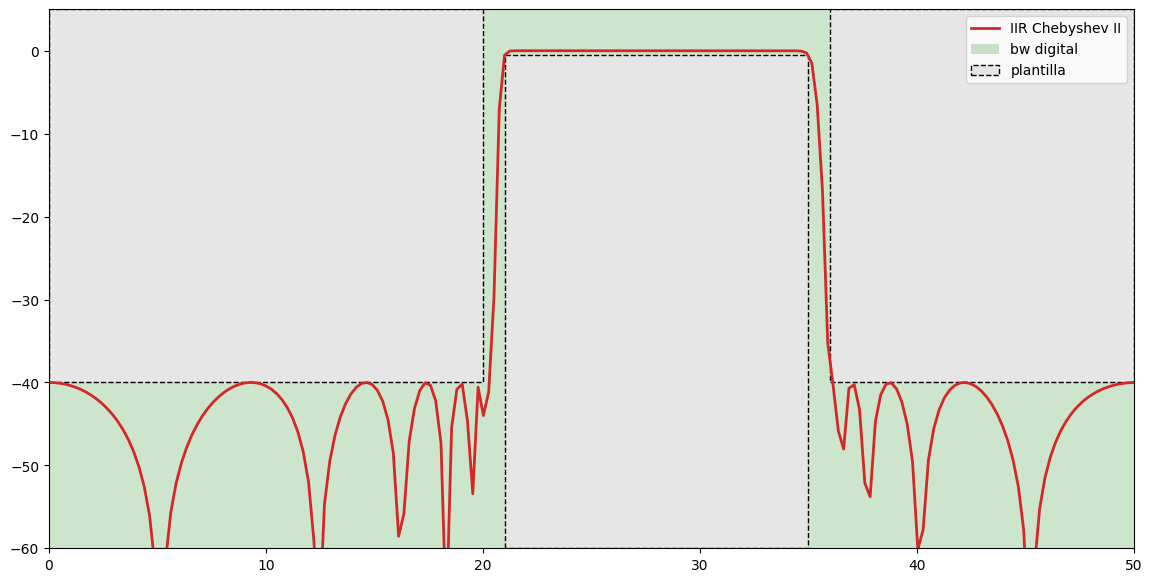

In [13]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from pytc2.sistemas_lineales import plot_plantilla

# =========================================================
# Parámetros generales
# =========================================================
ripple = 0.5      # dB de ripple en banda pasante
atenuacion = 40   # dB de atenuación en banda de rechazo
fs = 1000         # Hz
nyq_frec = fs / 2
fig_sz_x = 14
fig_sz_y = 7

# =========================================================
# Frecuencias de plantilla
# =========================================================
ws1 = 20
wp1 = 21
wp2 = 35.0
ws2 = 36

# =========================================================
# Diseño del filtro IIR Chebyshev II
# =========================================================
sos_iir = sig.iirdesign(
    wp=[wp1, wp2],
    ws=[ws1, ws2],
    gpass=ripple,
    gstop=atenuacion,
    ftype='cheby2',
    output='sos',
    fs=fs
)

# =========================================================
# Respuesta en frecuencia
# =========================================================
w, h_iir = sig.freqz_sos(sos_iir, worN=2048, fs=fs)
H_dB = 20 * np.log10(np.abs(h_iir) + 1e-12)

# =========================================================
# Gráfico conjunto: plantilla + IIR
# =========================================================
plt.figure(figsize=(fig_sz_x, fig_sz_y))
plt.axis([0, 50, -60, 5])

# Curva de magnitud del filtro IIR
plt.plot(w, H_dB, label='IIR Chebyshev II', color='C3', linewidth=2)

# Plantilla de diseño superpuesta
plot_plantilla(
    filter_type='bandpass',
    fpass=(wp1, wp2),
    fstop=(ws1, ws2),
    ripple=ripple,
    attenuation=atenuacion,
    fs=fs
)



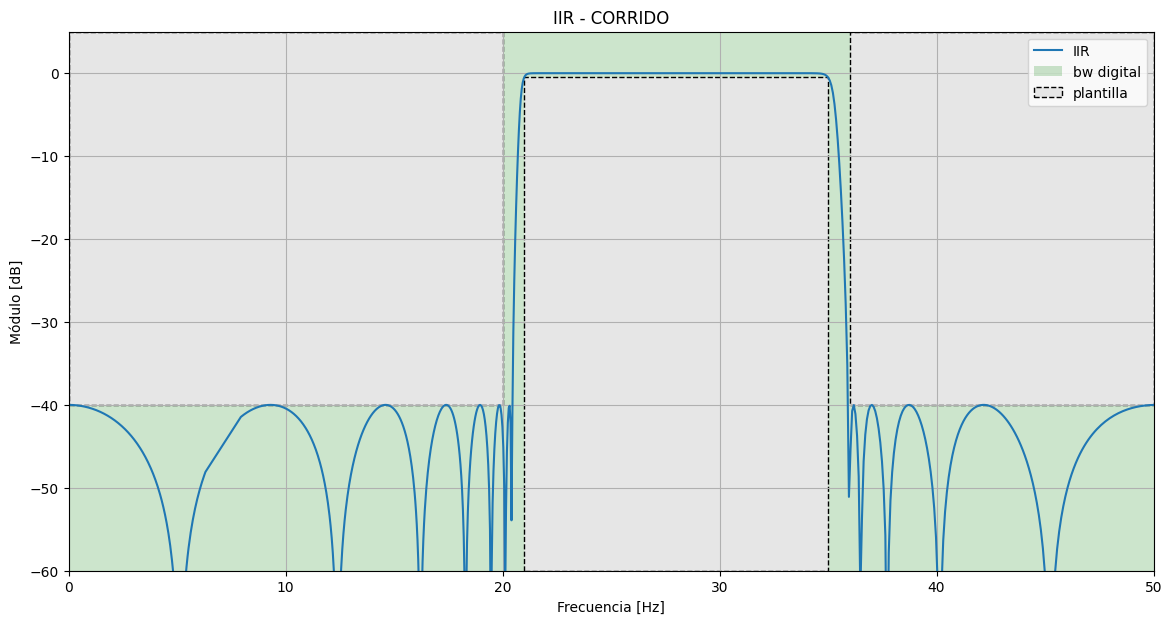

In [14]:
# @title Filtro IIR_DESIGN

# --- Diseño IIR (Chebyshev II) en SOS ---
sos_iir = sig.iirdesign(
    wp=[wp1, wp2],
    ws=[ws1, ws2],
    gpass=ripple,
    gstop=atenuacion,
    output='sos',
    analog=False,
    ftype='cheby2',
    fs=fs
)

sos_iir_1 = sos_iir  # copia explícita de referencia

# --- Malla de frecuencias (mixta: log y lin) ---
w_rad = np.append(np.logspace(-3, 0.8, 1000), np.logspace(0.9, 1.8, 1000))
w_rad = np.append(w_rad, np.linspace(64, nyq_frec, 1000, endpoint=True))

# --- Respuesta en frecuencia ---
w_rad, h_iir = sig.freqz_sos(sos_iir, worN=w_rad, fs=fs)

# --- Plot magnitud ---
plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.plot(w_rad, 20 * np.log10(np.abs(h_iir) + 1e-12), label='IIR')
plt.title('IIR - CORRIDO')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([0, 50, -60, 5])

axes_hdl = plt.gca()

# --- Plantilla (bandpass) ---
plot_plantilla(
    filter_type='bandpass',
    fpass=(wp1, wp2),
    fstop=(ws1, ws2),
    ripple=ripple,
    attenuation=atenuacion,
    fs=fs
)
_ = axes_hdl.legend()


# Respuesta del filtro

La banda de paso, esta entre 20 hz y 35 hz aproximadamente

### 18 Hz *(Banda de stop inferior)*
Se observa como la señal, esta totalmente atenuada. Coincidiendo con el resultado del filtro
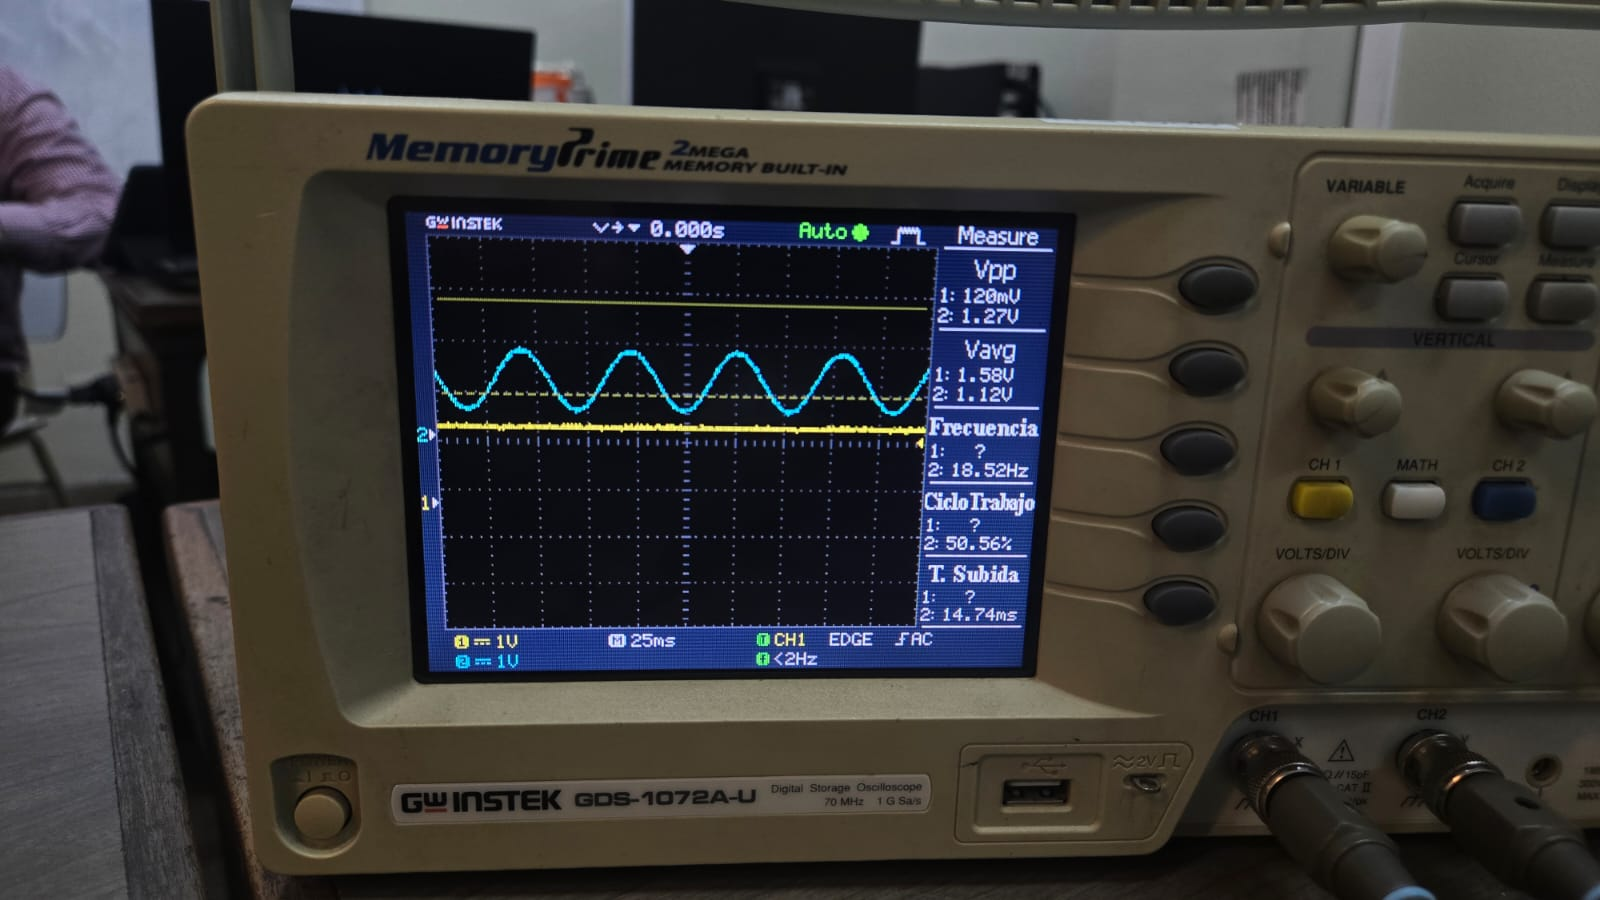

### 24Hz *(Banda de paso)*
Se observa como la señal, Al estar tambien en banda de paso, no se atenua
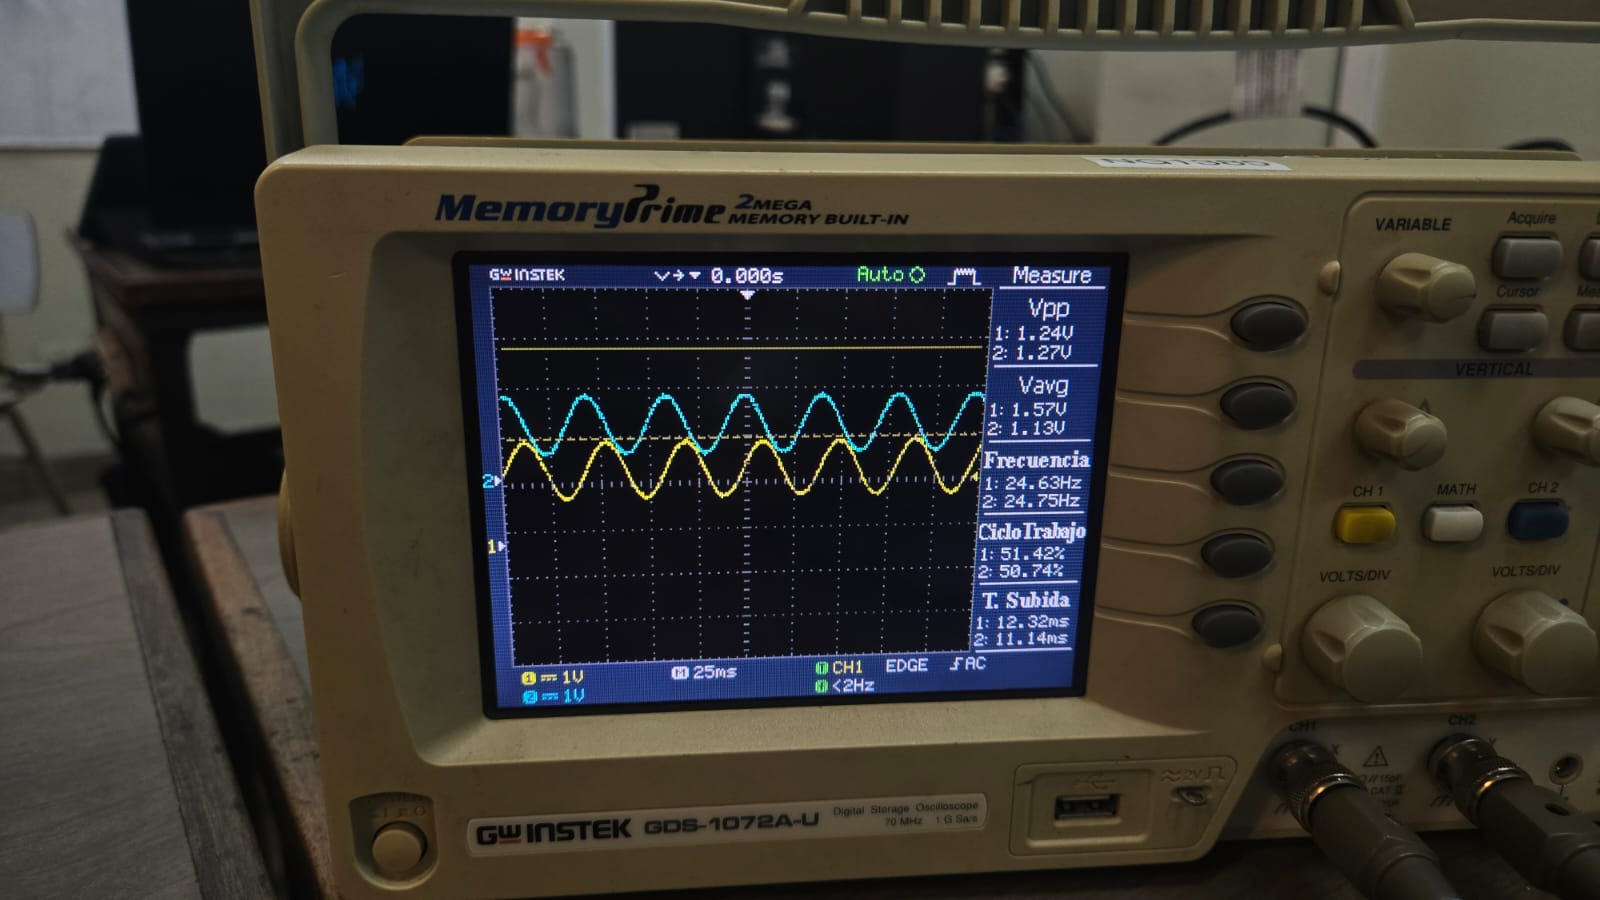

### 38 HZ *(Banda de stop superior)*
Se observa como la señal, Al estar tambien en banda de stop, se atenua fuertemente
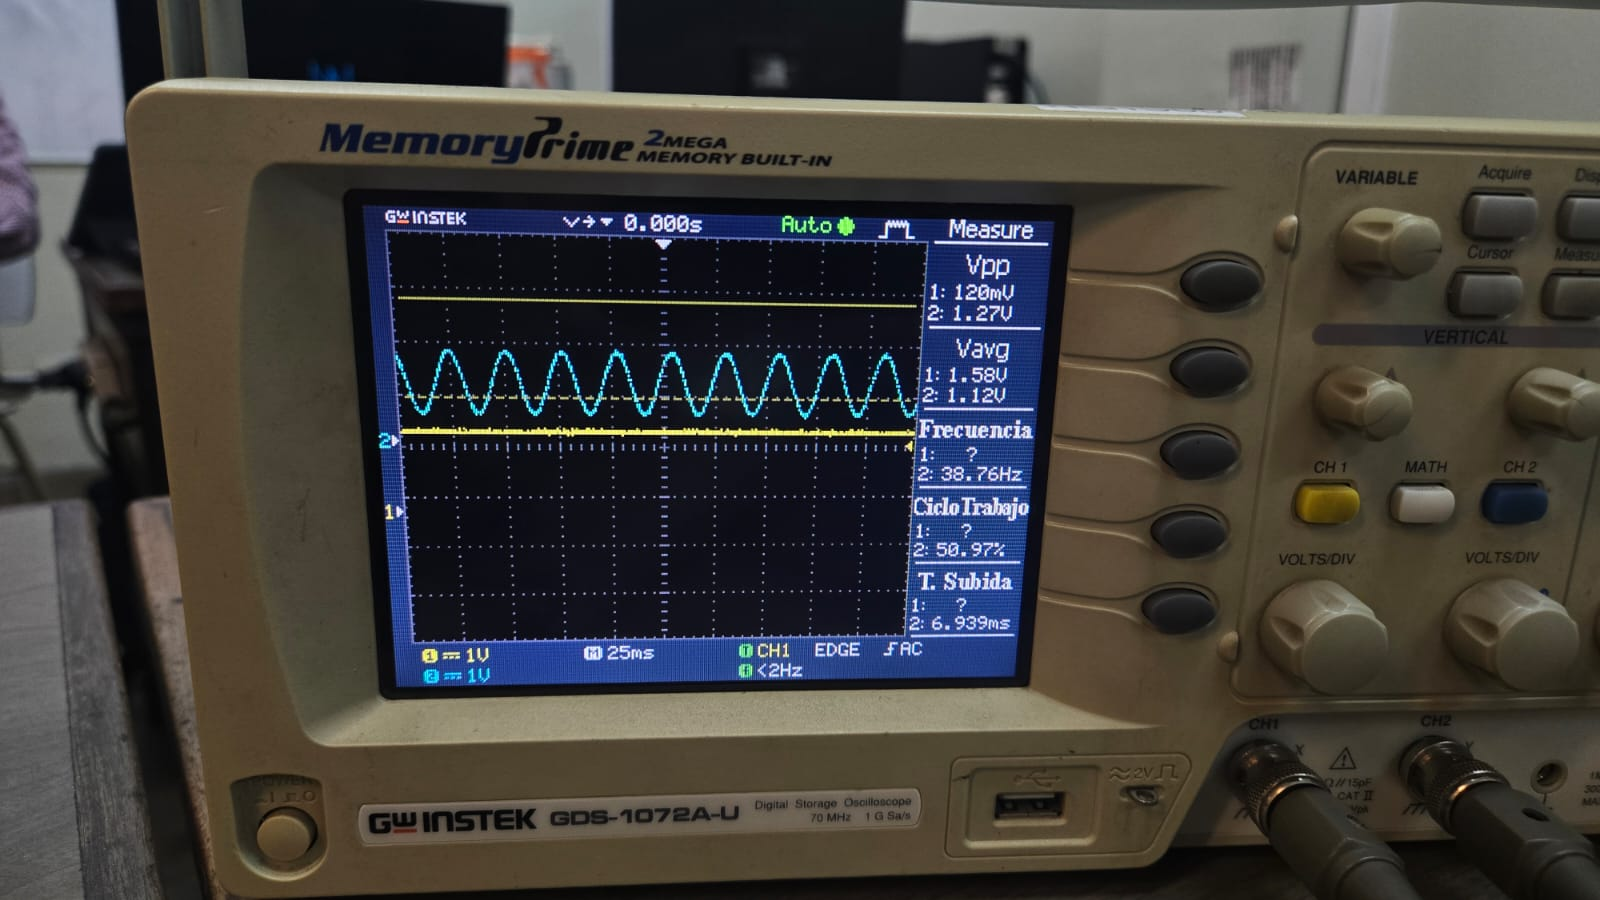

## Respuesta de analizador de espectro

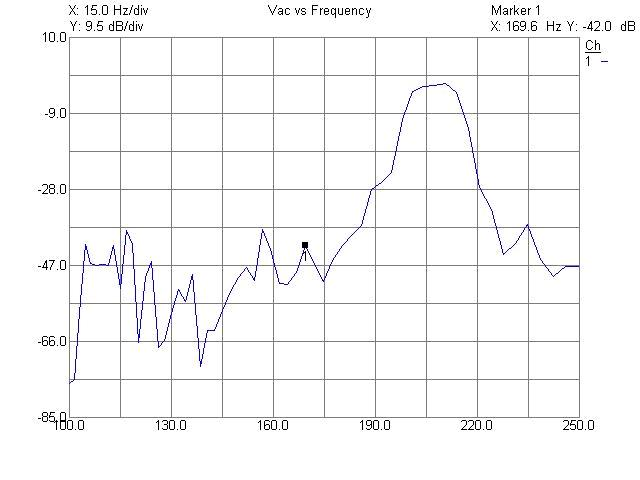


Al igual que con el filtro FIR, esta respuesta se encuentra desplazada de su valor teorico. Nuevamente, se atribuye esto a una posible des-sincronizacion de la frecuencia de muestreo del microcontrolador

Como conclusion se puede ver que el microcontrolador funciona suficientemente bien como reemplazo de los circuitos analogicos. Pero tambien complica el computo necesario para poder llegar al resultado deseado y el codigo necesario para que funcione correctamente. Pero en ultima instancia se pudo ver el potencial que tiene este tipo de procedimiento comparado con hacerlo de manera digital. 
